In [1]:
# my code 
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9
datasets.disable_caching()

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Note: We need to re-train Sara 2's model, because it was trained with 12 output classes and on completely different data. 
We're only testing the model structure (i.e. LSTM), not their actual model. 

In [2]:
from sklearn.utils.class_weight import compute_class_weight 
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.model_selection import StratifiedKFold, KFold
from transformers import set_seed 
import copy
set_seed(42)

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')  

In [7]:
from utils.load_data import preprocess
from datasets import concatenate_datasets 
val_dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
val_dataset = val_dataset.remove_columns('KSAT ID')
val_dataset = val_dataset.map(preprocess)
print(val_dataset)

from utils.load_data import preprocess_csec, preprocess_csec8
# CSEC2017 specific! CHANGED: train_CSEC2017b to train_CSEC2017c to include class 0 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
dataset = dataset.remove_columns('Statement Description')
dataset = dataset.remove_columns('label')
print(dataset)
dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
print(dataset)
dataset = dataset.map(preprocess_csec)
print(dataset)
train_dataset = concatenate_datasets([val_dataset, dataset])
print(train_dataset)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 576
})
Dataset({
    features: ['Unnamed: 0', 'topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 13'],
    num_rows: 2143
})
Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8'],
    num_rows: 2143
})


Map:   0%|          | 0/2143 [00:00<?, ? examples/s]

Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2143
})
Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels', 'topics'],
    num_rows: 2719
})


In [8]:
# Use the .map function to get all tokens, or a more efficient method
all_input_ids = []
for example in train_dataset:
    all_input_ids.extend(example['input_ids'])

num_unique_ids = len(set(all_input_ids))
print(f"The 'input_ids' column contains {num_unique_ids} unique token IDs.")

The 'input_ids' column contains 2739 unique token IDs.


In [9]:
from collections import defaultdict
import numpy as np
from datasets import Dataset

def create_remapping_function(dataset, input_ids_column='input_ids'):
    """
    Creates a function that remaps input_ids to a condensed 0-(n-1) range.
    
    Args:
        dataset: Hugging Face Dataset
        input_ids_column: Name of the column containing input_ids
    
    Returns:
        tuple: (remap_function, id_mapping, reverse_mapping)
    """
    # Step 1: Collect all unique input_ids
    print("Collecting unique token IDs...")
    all_ids = set()
    for example in dataset:
        all_ids.update(example[input_ids_column])
    
    # Step 2: Create mapping from old IDs to new IDs (0, 1, 2, ...)
    unique_ids = sorted(all_ids)  # Sort for consistent ordering
    id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_ids)}
    reverse_mapping = {new_id: old_id for old_id, new_id in id_mapping.items()}
    
    print(f"Created mapping for {len(unique_ids)} unique tokens")
    print(f"Original ID range: {min(unique_ids)} to {max(unique_ids)}")
    print(f"New ID range: 0 to {len(unique_ids)-1}")
    
    # Step 3: Create the remapping function
    def remap_function(example):
        example[input_ids_column] = [id_mapping[token_id] for token_id in example[input_ids_column]]
        return example
    
    return remap_function, id_mapping, reverse_mapping

# Usage example:
def remap_dataset_ids(dataset, input_ids_column='input_ids'):
    """
    Main function to remap the dataset's input_ids to condensed range.
    
    Args:
        dataset: Hugging Face Dataset
        input_ids_column: Name of the column containing input_ids
    
    Returns:
        tuple: (remapped_dataset, id_mapping, reverse_mapping)
    """
    # Create the remapping function and mappings
    remap_func, id_mapping, reverse_mapping = create_remapping_function(
        dataset, input_ids_column
    )
    
    # Apply the mapping to the dataset
    print("Applying remapping to dataset...")
    remapped_dataset = dataset.map(
        remap_func,
        batched=False,
        desc="Remapping token IDs"
    )
    
    return remapped_dataset, id_mapping, reverse_mapping

# Assuming your dataset is called 'dataset'
remapped_dataset, id_mapping, reverse_mapping = remap_dataset_ids(train_dataset)

# Verify the results
print("\n=== Verification ===")
print(f"Original dataset size: {len(train_dataset)}")
print(f"Remapped dataset size: {len(remapped_dataset)}")

# Check a few examples
print("\nFirst example - Original vs Remapped:")
print("Original:", train_dataset[0]['input_ids'][:10])  # First 10 tokens
print("Remapped:", remapped_dataset[0]['input_ids'][:10])

# Verify uniqueness and range
all_remapped_ids = set()
for example in remapped_dataset:
    all_remapped_ids.update(example['input_ids'])

print(f"\nUnique IDs in remapped dataset: {len(all_remapped_ids)}")
print(f"Range in remapped dataset: {min(all_remapped_ids)} to {max(all_remapped_ids)}")

Created mapping for 2739 unique tokens
Original ID range: 101 to 29589
New ID range: 0 to 2738
Applying remapping to dataset...


Remapping token IDs:   0%|          | 0/2719 [00:00<?, ? examples/s]


=== Verification ===
Original dataset size: 2719
Remapped dataset size: 2719

First example - Original vs Remapped:
Original: [101, 3274, 14048, 8474, 1998, 16744, 1010, 1998, 2897, 3036]
Remapped: [0, 524, 1984, 1457, 38, 2164, 7, 38, 410, 449]

Unique IDs in remapped dataset: 2739
Range in remapped dataset: 0 to 2738


In [12]:
X = train_dataset['input_ids']
y = train_dataset['labels']

# plot distribution labels 
#print(val_dataset['labels'][1:10])
print(y[1:10])
print(y[2700:2710])
print(np.sum(np.array(y),axis=0))
#y_new = get_new_labels(data['labels'])
X = remapped_dataset['input_ids']

[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]]
[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0], [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0]]
[433. 433. 333. 215. 383. 348. 326. 825. 409.]


In [15]:
import torch
import torch.nn as nn
import numpy as np
import os
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

model_config = {'tag_size': 9, 'vocab_size': max(max(X))+2, 'embedding_dim': 100, 'layers': [128], 'jagged': True, 'bidirectional': False} 
trainer_config = {'batch_size': 10 , 'scheduler_step_size': 20, 'learning_rate': 0.001, 'scheduler_gamma': 0.99}
print(model_config)

{'tag_size': 9, 'vocab_size': 2740, 'embedding_dim': 100, 'layers': [128], 'jagged': True, 'bidirectional': False}


In [16]:
def truncated_normal_(tensor, mean=0, std=1):
    size = tensor.shape
    tmp = tensor.new_empty(size + (4,)).normal_()
    valid = (tmp < 2) & (tmp > -2)
    ind = valid.max(-1, keepdim=True)[1]
    tensor.data.copy_(tmp.gather(-1, ind).squeeze(-1))
    tensor.data.mul_(std).add_(mean)
    return tensor

def initialize_weights(net, initrange=1.0):
    for m in net.modules():
        if isinstance(m, nn.Linear):
            initrange *= 1.0/np.sqrt(m.weight.data.shape[1])
            m.weight.data = initrange * \
                truncated_normal_(m.weight.data, mean=0.0, std=1)
            m.bias.data.zero_()
        elif isinstance(m, nn.Embedding):
            truncated_normal_(m.weight.data, mean=0.0, std=1)

class LSTMLanguageModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.vocab_size = config['vocab_size']
        self.embedding_dim = config['embedding_dim']
        self.layers = config['layers']
        self.jagged = config['jagged']
        self.tag_size = config['tag_size']
        # Layers
        self.embeddings = nn.Embedding(self.vocab_size, self.embedding_dim)
        self.stacked_lstm = nn.LSTM(self.embedding_dim, self.layers[0], len(self.layers), batch_first=True, bidirectional=config['bidirectional'])
        
        fc_input_dim = self.layers[-1]

        if config['bidirectional']: # If LSMTM is bidirectional, its output hidden states will be twice as large
            fc_input_dim *= 2

        self.hidden2tag = nn.Linear(fc_input_dim, self.vocab_size)

        # Weight initialization
        initialize_weights(self)
    
    @property
    def bidirectional(self):
        raise NotImplementedError("Bidirectional property has to be set in child class.")

    def forward(self, sequences, lengths=None, context_vectors=None):
        # batch size, sequence length, embedded dimension
        x_lookups = self.embeddings(sequences)
        lstm_in = x_lookups
        if self.jagged:
            lstm_in = pack_padded_sequence(
                lstm_in, lengths, enforce_sorted=False, batch_first=True)
        lstm_out, (hx, cx) = self.stacked_lstm(lstm_in)
        if self.jagged:
            lstm_out = pad_packed_sequence(lstm_out, batch_first=True)
            lstm_out = lstm_out[0]
        return lstm_out, hx

class Fwd_Job_LSTM(LSTMLanguageModel):
    def __init__(self, config, glove_mat = None):
        self.name = "LSTM_job"
        super().__init__(config)
        fc_input_dim = self.layers[-1]

        if glove_mat is not None:
            self.embeddings = nn.Embedding.from_pretrained(glove_mat)#, freeze=True)
        self.hidden2hidden = nn.Linear(fc_input_dim*2, fc_input_dim*2)
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.hidden2tag = nn.Linear(fc_input_dim*2, self.tag_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, sequences, lengths=None, context_vectors=None):
        lstm_out, hx = super().forward(sequences, lengths, context_vectors)
    
        lstm_mean = torch.mean(lstm_out, axis = 1)
        output = torch.cat((lstm_out[:, -1, :], lstm_mean), axis = 1)
        hidden_output0 = self.hidden2hidden(output)
        hidden_output1= self.leaky_relu(hidden_output0)

        tag_size = self.hidden2tag(hidden_output1)
        tag_output = self.sigmoid(tag_size)

        return tag_size, tag_output

In [27]:
from torch.nn.utils.rnn import pad_sequence
class Jagged_text(Dataset):
    def __init__(self, dataset, cuda=False):
        self.X = dataset['input_ids']
        self.Y = dataset['labels']
        self.cuda = cuda
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Convert to tensors
        X = torch.tensor(self.X[idx])
        Y = torch.tensor(self.Y[idx])
        L = torch.tensor(len(X), dtype=torch.long)
        
        # Return exactly 3 elements
        return X, Y, L

def custom_collate_fn(batch):
    """
    Custom collate function that handles variable length for both X and Y
    """
    X_batch = []
    Y_batch = []
    L_batch = []
    
    for item in batch:
        X_batch.append(item[0])
        Y_batch.append(item[1])
        L_batch.append(item[2])
    
    # Pad sequences for X
    X_padded = pad_sequence(X_batch, batch_first=True, padding_value=0)
    
    # Handle Y - check if we need to pad or stack
    if all(y.dim() == 0 for y in Y_batch):  # All Y are scalars
        Y_stacked = torch.stack(Y_batch, dim=0)
    elif all(y.shape == Y_batch[0].shape for y in Y_batch):  # All Y have same shape
        Y_stacked = torch.stack(Y_batch, dim=0)
    else:  # Y has variable length, need padding
        Y_stacked = pad_sequence(Y_batch, batch_first=True, padding_value=0)
    
    L_stacked = torch.stack(L_batch, dim=0)
    
    return X_padded, Y_stacked, L_stacked

# Create datasets
processed = Jagged_text(remapped_dataset, cuda=False)
train_dataset, test_dataset = train_test_split(processed, test_size=0.10, random_state=0)

# Use the robust collate function
train_loader = DataLoader(
    train_dataset, 
    batch_size=trainer_config['batch_size'],
    shuffle=True, 
    num_workers=0,
    collate_fn=custom_collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=trainer_config['batch_size'],
    shuffle=True, 
    num_workers=0,
    collate_fn=custom_collate_fn
)

print(len(train_loader))
print(len(test_loader))

245
28


In [28]:
print(trainer_config)
trainer_config['learning_rate'] = 0.001
trainer_config['batch_size'] = 10
print(trainer_config)

{'batch_size': 10, 'scheduler_step_size': 20, 'learning_rate': 0.001, 'scheduler_gamma': 0.99}
{'batch_size': 10, 'scheduler_step_size': 20, 'learning_rate': 0.001, 'scheduler_gamma': 0.99}


In [29]:
class Trainer(): 
    def __init__(self,model_config,trainer_config): 
        self.model = Fwd_Job_LSTM(model_config).cuda()
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=trainer_config['learning_rate'])
        
    def train_step(self, batch):
        """Defines a single training step. Feeds data through the model, computes the loss and makes an optimization step."""
        self.model.train()
        self.optimizer.zero_grad()
        # Split the batch into input, ground truth, etc.
        X, Y, L= batch
        # Apply the model to input to produce the output
        output, sigmoid_output = self.model(X.cuda(), lengths=L)
        # Compute the loss for the output
        loss = self.criterion(output, Y.float().cuda())
        # Take an optimization step based on the loss
        self.optimizer_step(loss)
        return loss
        
    def optimizer_step(self, loss):
        """Performs one step of optimization on the given loss."""
        loss.backward()
        self.optimizer.step()

In [41]:
# training loop with KFold 
from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score 
epochs = 20
cuda = True
train_losses = []
test_accs = []

n_repeats = 5 # number of seeds 
n_splits = 10 # number of k splits 
precisions = []
recalls = [] 
f1s = [] 
accs = []
best_f1 = 0
# Store best metrics for each fold
best_fold_metrics = []
for _ in range(n_repeats): 
    kf = KFold(n_splits=n_splits,  shuffle=True) 

    for i, (train, test) in enumerate(kf.split(processed)):  # split into k-folds
        print('split ',i)
        trainer = Trainer(model_config, trainer_config)
        # Create subsets using indices
        train_subset = torch.utils.data.Subset(processed, train)
        test_subset = torch.utils.data.Subset(processed, test)
        
        train_loader = DataLoader(
        train_subset, 
        batch_size=trainer_config['batch_size'],
        shuffle=True, 
        num_workers=0,
        collate_fn=custom_collate_fn
        )
    
        test_loader = DataLoader(
        test_subset, 
        batch_size=trainer_config['batch_size'],
        shuffle=True, 
        num_workers=0,
        collate_fn=custom_collate_fn
        )

        # Track best metrics for this fold
        best_fold_f1 = 0
        best_fold_metrics_current = {}
        for epoch in tqdm(range(epochs)):
            precision = 0 
            recall = 0 
            f1 = 0 
            acc = 0 
            num_total_prediction = 0
            trainer.model.train()
            for iteration, batch in enumerate(train_loader):
                loss = trainer.train_step(batch)
                train_losses.append(loss.item())
            print('mean train loss: ',np.mean(train_losses))
        
            trainer.model.eval()
            wrong_prediction = torch.tensor(0)
            num_total_prediction = torch.tensor(0)
            with torch.no_grad(): 
                for iteration, batch in enumerate(test_loader):
                    X, Y, L = batch
                    T = trainer.model(X.cuda(), L)
                    t = T[1]>0.5
                    t = t.detach().cpu().int()
                    report = classification_report(Y.tolist(),t
                                                       ,output_dict=True, zero_division=0)
                    wrong_prediction += torch.abs(t - Y.int()).sum()
                    num_total_prediction += Y.shape[0]*Y.shape[1]
                    test_acc = (1 - wrong_prediction / num_total_prediction)
                    test_accs.append(test_acc)
                    accuracy = accuracy_score(Y.tolist(), t)
                    acc += accuracy *len(batch)/len(test)
                    precision += report['macro avg']['precision'] *len(batch)/len(test)
                    recall += report['macro avg']['recall'] *len(batch)/len(test)
                    f1 += report['macro avg']['f1-score']  *len(batch)/len(test)

            # Calculate final metrics for this epoch
            epoch_f1 = np.mean(f1)
            epoch_precision = np.mean(precision)
            epoch_recall = np.mean(recall)
            epoch_acc = np.mean(test_accs)
            
            print('mean val acc: ',np.mean(test_accs))
            print('mean precision: ',epoch_precision)
            print('mean recall: ',epoch_recall)
            print('f1: ',epoch_f1)
            
            # Check if this is the best F1 for this fold
            if epoch_f1 > best_fold_f1:
                best_fold_f1 = epoch_f1
                best_fold_metrics_current = {
                    'fold': i,
                    'epoch': epoch,
                    'f1': epoch_f1,
                    'precision': epoch_precision,
                    'recall': epoch_recall,
                    'accuracy': epoch_acc,
                    'test_accuracy': np.mean(test_accs)
                }
            
            precisions.append(precision)
            recalls.append(recall) 
            f1s.append(f1)
        
        # Store best metrics for this fold
        best_fold_metrics.append(best_fold_metrics_current)

split  0


  0%|                                                                                                                            | 0/20 [00:00<?, ?it/s]

mean train loss:  0.45235305854252406


  5%|█████▊                                                                                                              | 1/20 [00:01<00:31,  1.66s/it]

mean val acc:  0.85788804
mean precision:  0.0
mean recall:  0.0
f1:  0.0
mean train loss:  0.42722148621568873


...

mean val acc:  0.87492156
mean precision:  0.12932993615650443
mean recall:  0.1272857728577286
f1:  0.12158502970311089
mean train loss:  0.14139940058674527


 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [01:00<00:02,  2.51s/it]

mean val acc:  0.87493
mean precision:  0.1261582615826158
mean recall:  0.12445674456744565
f1:  0.11847982549089561
mean train loss:  0.14127460268520725


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:02<00:00,  3.15s/it]

mean val acc:  0.8749329
mean precision:  0.12718327183271835
mean recall:  0.11871668716687167
f1:  0.11646849801831352


In [44]:
# Print summary of best performances
print("\n=== BEST F1 SCORES PER FOLD ===")
for metrics in best_fold_metrics:
    print(f"Fold {metrics['fold']}: Epoch {metrics['epoch']}, "
          f"F1: {metrics['f1']:.4f}, Accuracy: {metrics['accuracy']:.4f}")

# Calculate average best F1 across folds
avg_best_f1 = np.mean([m['f1'] for m in best_fold_metrics])
print(f"\nAverage Best F1 across all folds: {avg_best_f1:.4f}")

avg_best_f1 = np.mean([m['precision'] for m in best_fold_metrics])
print(f"\nAverage Best precision across all folds: {avg_best_f1:.4f}")

avg_best_f1 = np.mean([m['recall'] for m in best_fold_metrics])
print(f"\nAverage Best recall across all folds: {avg_best_f1:.4f}")

avg_best_f1 = np.std([m['f1'] for m in best_fold_metrics])
print(f"\nAverage Best F1 across all folds: {avg_best_f1:.4f}")

avg_best_f1 = np.std([m['precision'] for m in best_fold_metrics])
print(f"\nAverage Best precision across all folds: {avg_best_f1:.4f}")

avg_best_f1 = np.std([m['recall'] for m in best_fold_metrics])
print(f"\nAverage Best recall across all folds: {avg_best_f1:.4f}")


=== BEST F1 SCORES PER FOLD ===
Fold 0: Epoch 11, F1: 0.1256, Accuracy: 0.8738
Fold 1: Epoch 16, F1: 0.1216, Accuracy: 0.8691
Fold 2: Epoch 10, F1: 0.1150, Accuracy: 0.8690
Fold 3: Epoch 11, F1: 0.1290, Accuracy: 0.8690
Fold 4: Epoch 11, F1: 0.1298, Accuracy: 0.8710
Fold 5: Epoch 17, F1: 0.1301, Accuracy: 0.8713
Fold 6: Epoch 15, F1: 0.1384, Accuracy: 0.8724
Fold 7: Epoch 14, F1: 0.1271, Accuracy: 0.8730
Fold 8: Epoch 15, F1: 0.1274, Accuracy: 0.8744
Fold 9: Epoch 17, F1: 0.1265, Accuracy: 0.8750
Fold 0: Epoch 16, F1: 0.1358, Accuracy: 0.8761
Fold 1: Epoch 16, F1: 0.1261, Accuracy: 0.8759
Fold 2: Epoch 10, F1: 0.1236, Accuracy: 0.8756
Fold 3: Epoch 12, F1: 0.1201, Accuracy: 0.8758
Fold 4: Epoch 15, F1: 0.1306, Accuracy: 0.8763
Fold 5: Epoch 18, F1: 0.1174, Accuracy: 0.8763
Fold 6: Epoch 16, F1: 0.1306, Accuracy: 0.8763
Fold 7: Epoch 13, F1: 0.1378, Accuracy: 0.8764
Fold 8: Epoch 10, F1: 0.1224, Accuracy: 0.8762
Fold 9: Epoch 10, F1: 0.1141, Accuracy: 0.8761
Fold 0: Epoch 17, F1: 0.130

In [25]:
# training loop 
from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score 
epochs = 20
cuda = True

trainer = Trainer(model_config, trainer_config)
train_losses = []
test_accs = []
n_repeats = 5 # number of seeds 
n_splits = 10 # number of k splits 
precisions = []
recalls = [] 
f1s = [] 
accs = []

for epoch in tqdm(range(epochs)):
    num_total_prediction = 0
    trainer.model.train()
    for iteration, batch in enumerate(train_loader):
        loss = trainer.train_step(batch)
        train_losses.append(loss.item())
    print('mean train loss: ',np.mean(train_losses))

    trainer.model.eval()
    wrong_prediction = torch.tensor(0)
    num_total_prediction = torch.tensor(0)
    precision = 0 
    recall = 0 
    f1 = 0 
    acc = 0 
     
    with torch.no_grad(): 
        for iteration, batch in enumerate(test_loader):
            X, Y, L = batch
            T = trainer.model(X.cuda(), L)
            t = T[1]>0.5
            t = t.detach().cpu().int()
            report = classification_report(Y.tolist(),t
                                               ,output_dict=True, zero_division=0)
            wrong_prediction += torch.abs(t - Y.int()).sum()
            num_total_prediction += Y.shape[0]*Y.shape[1]
            test_acc = (1 - wrong_prediction / num_total_prediction)
            test_accs.append(test_acc)
            accuracy = accuracy_score(Y.tolist(), t)
            acc += (accuracy * len(batch)) / len(test_loader.dataset)
            precision += (report['macro avg']['precision'] * len(batch)) / len(test_loader.dataset)
            recall += (report['macro avg']['recall'] * len(batch)) / len(test_loader.dataset)
            f1 += (report['macro avg']['f1-score'] * len(batch)) / len(test_loader.dataset)
    print(sum(sum(t)))
    print('mean acc: ',np.mean(acc))
    print('mean val acc: ',np.mean(test_accs))
    print('mean precision: ',np.mean(precision))
    print('mean recall: ',np.mean(recall))
    print('f1: ',np.mean(f1))
    

  0%|                                                                                                                                                                                                                                                           | 0/20 [00:00<?, ?it/s]

mean train loss:  0.4448217378587139


  5%|████████████▏                                                                                                                                                                                                                                      | 1/20 [00:01<00:28,  1.52s/it]

tensor(0, dtype=torch.int32)
mean acc:  0.0
mean val acc:  0.8512287
mean precision:  0.0
mean recall:  0.0
f1:  0.0
mean train loss:  0.4147750485916527


 10%|████████████████████████▎                                                                                                                                                                                                                          | 2/20 [00:03<00:27,  1.55s/it]

...

tensor(2, dtype=torch.int32)
mean acc:  0.12132352941176469
mean val acc:  0.8770031
mean precision:  0.11184348739495799
mean recall:  0.11011029411764703
f1:  0.10522875816993461
mean train loss:  0.14186882754318125


 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉            | 19/20 [00:27<00:01,  1.45s/it]

tensor(3, dtype=torch.int32)
mean acc:  0.12463235294117646
mean val acc:  0.87689656
mean precision:  0.11399101307189544
mean recall:  0.10774976657329599
f1:  0.10390024599583425
mean train loss:  0.13547250036666736


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:29<00:00,  1.46s/it]

tensor(3, dtype=torch.int32)
mean acc:  0.12794117647058825
mean val acc:  0.8773233
mean precision:  0.12109885620915034
mean recall:  0.12853349673202613
f1:  0.11920367894632604


In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data, self.y_new)): 
            print(f"Training on fold {fold + 1}")
            self.train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.val_dataset = copy.deepcopy(val_dataset)

In [ ]:
multi_train_losses = []
multi_train_test_accs = []
multi_train_acc = []
multi_test_acc = []

for i in range(10): 
    lstm_model = Fwd_Job_LSTM(model_config)
    trainer = Trainer(lstm_model, model_config, trainer_config, verbose, checkpoint_dir)
    train_losses, test_accs = train_model(trainer, train_loader, test_loader, 50, cuda=torch.cuda.is_available())
    multi_train_losses.append(train_losses)
    multi_train_test_accs.append(test_accs)

    train_acc = eval_model(trainer, train_loader, cuda=torch.cuda.is_available())
    multi_train_acc.append(train_acc)

    test_acc = eval_model(trainer, test_loader, cuda=torch.cuda.is_available())
    multi_test_acc.append(test_acc)

### Model description: 
Takes in BERT tokenized sample 
Then uses a 128 unit LSTM and 256 dimension ANN layer? 
I'm speculating that the 12 ECSF profiles with 84 skills and 69 knowledges form the classes, and that only one class is true at a time. 

In [ ]:
 parser.add_argument('--cut-rank', type=int, help="Cut rank for statistics.", default = 10)
    # Path of files and folder for a LSTM model.
    parser.add_argument("--token-path", type=str, help="Path to tokenized numpy file.")
    parser.add_argument("--truth-path", type=str, help="Path to tokenized numpy file.")
    # Parameters for models.
    parser.add_argument('--random_state', type=int, help='randome state for split train test', default=0)
    parser.add_argument('--epochs', type=int, help='Epochs for training loop', default=200)
    parser.add_argument('--batch-size', type=int, help='Size of one batch', default=64)
    parser.add_argument('--scheduler-step-size', type=int, help='Steps for decaying learning rate ', default=10)
    parser.add_argument('--scheduler-gamma', type=float, help='Factor of decaying learning rate', default=0.9)
    parser.add_argument('--dropout', type=float, help='Dropout rate for model', default=0.2)
    parser.add_argument('--learning-rate', type=float, help='Initial learning rate', default=0.001)
    parser.add_argument('--embedding-dim', type=int, help='Embedding dimention', default = 128)
    parser.add_argument('--layers', nargs="+", type=int, default=[128])
    parser.add_argument('--num-repeat-test', type=int, help='k-fold cross validcation', default=3)
    parser.add_argument('-v', '--verbose', action='store_true')


# Data preparation

Read data 'subword_token_hund.npy' and 'subword_truth_hund.npy'.

In [7]:
token = 'subword_token.npy'
truth = 'subword_truth.npy'
data_path = 'data/tokenization_result'

cwd = os.getcwd()
verbose = False
checkpoint_dir = ''

X_path = os.path.join(cwd, data_path, token)
Y_path = os.path.join(cwd, data_path, truth)

with open(X_path, 'rb') as f:
    X = torch.tensor(np.load(f)).int()
with open(Y_path, 'rb') as f:
    Y = torch.tensor(np.load(f)).int()

model_config = {'tag_size': Y.shape[-1], 'vocab_size': torch.max(X[:,:-1])+2, 'embedding_dim': 100, 'layers': [128], 'jagged': True, 'bidirectional': False} 
trainer_config = {'batch_size': 10 , 'scheduler_step_size': 20, 'learning_rate': 0.001, 'scheduler_gamma': 0.99}

# LSTM model to process data.

In [8]:
def truncated_normal_(tensor, mean=0, std=1):
    size = tensor.shape
    tmp = tensor.new_empty(size + (4,)).normal_()
    valid = (tmp < 2) & (tmp > -2)
    ind = valid.max(-1, keepdim=True)[1]
    tensor.data.copy_(tmp.gather(-1, ind).squeeze(-1))
    tensor.data.mul_(std).add_(mean)
    return tensor

def initialize_weights(net, initrange=1.0):
    for m in net.modules():
        if isinstance(m, nn.Linear):
            initrange *= 1.0/np.sqrt(m.weight.data.shape[1])
            m.weight.data = initrange * \
                truncated_normal_(m.weight.data, mean=0.0, std=1)
            m.bias.data.zero_()
        elif isinstance(m, nn.Embedding):
            truncated_normal_(m.weight.data, mean=0.0, std=1)

class LSTMLanguageModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.vocab_size = config['vocab_size']
        self.embedding_dim = config['embedding_dim']
        self.layers = config['layers']
        self.jagged = config['jagged']
        self.tag_size = config['tag_size']
        # Layers
        self.embeddings = nn.Embedding(self.vocab_size, self.embedding_dim)
        self.stacked_lstm = nn.LSTM(self.embedding_dim, self.layers[0], len(self.layers), batch_first=True, bidirectional=config['bidirectional'])
        
        fc_input_dim = self.layers[-1]

        if config['bidirectional']: # If LSMTM is bidirectional, its output hidden states will be twice as large
            fc_input_dim *= 2

        self.hidden2tag = nn.Linear(fc_input_dim, self.vocab_size)

        # Weight initialization
        initialize_weights(self)
    
    @property
    def bidirectional(self):
        raise NotImplementedError("Bidirectional property has to be set in child class.")

    def forward(self, sequences, lengths=None, context_vectors=None):
        # batch size, sequence length, embedded dimension
        x_lookups = self.embeddings(sequences)
        lstm_in = x_lookups
        if self.jagged:
            lstm_in = pack_padded_sequence(
                lstm_in, lengths, enforce_sorted=False, batch_first=True)
        lstm_out, (hx, cx) = self.stacked_lstm(lstm_in)
        if self.jagged:
            lstm_out = pad_packed_sequence(lstm_out, batch_first=True)
            lstm_out = lstm_out[0]
        return lstm_out, hx

class Fwd_Job_LSTM(LSTMLanguageModel):
    def __init__(self, config, glove_mat = None):
        self.name = "LSTM_job"
        super().__init__(config)
        fc_input_dim = self.layers[-1]

        if glove_mat is not None:
            self.embeddings = nn.Embedding.from_pretrained(glove_mat)#, freeze=True)
        self.hidden2hidden = nn.Linear(fc_input_dim*2, fc_input_dim*2)
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.hidden2tag = nn.Linear(fc_input_dim*2, self.tag_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, sequences, lengths=None, context_vectors=None):
        lstm_out, hx = super().forward(sequences, lengths, context_vectors)
    
        lstm_mean = torch.mean(lstm_out, axis = 1)
        output = torch.cat((lstm_out[:, -1, :], lstm_mean), axis = 1)
        hidden_output0 = self.hidden2hidden(output)
        hidden_output1= self.leaky_relu(hidden_output0)

        tag_size = self.hidden2tag(hidden_output1)
        tag_output = self.sigmoid(tag_size)

        return tag_size, tag_output

In [17]:
print(model_config['jagged'])

True


# Trainer class

In [9]:
from abc import ABC

class Trainer(ABC):
    def __init__(self, model, model_config, trainer_config, verbose, checkpoint_dir):

        self.model = model
        # Check GPU
        self.cuda = torch.cuda.is_available()
        self.jagged = model_config['jagged']
        self.bidirectional = model_config['bidirectional']

        if self.cuda:
            self.model.cuda()

        # Create settings for training.
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=trainer_config['learning_rate'])
        self.scheduler = torch.optim.lr_scheduler.StepLR(
            self.optimizer, step_size=trainer_config['scheduler_step_size'], gamma=trainer_config['scheduler_gamma'])

    def compute_loss(self, output, Y, lengths, mask):
        """Computes the loss for the given model output and ground truth."""
        if self.jagged:
            if self.bidirectional:
                token_losses = self.criterion(
                    output.transpose(1, 2), Y[:, 1:max(lengths)-1])
                masked_losses = token_losses * mask[:, 1:max(lengths)-1]
            else:
                token_losses = self.criterion(
                    output.transpose(1, 2), Y[:, :max(lengths)])
                masked_losses = token_losses * mask[:, :max(lengths)]
            line_losses = torch.sum(masked_losses, dim=1)
        else:
            token_losses = self.criterion(output.transpose(1, 2), Y)
            line_losses = torch.mean(token_losses, dim=1)
        loss = torch.mean(line_losses, dim=0)

        return loss

    def train_step(self, batch):
        """Defines a single training step. Feeds data through the model, computes the loss and makes an optimization step."""

        self.model.train()
        self.optimizer.zero_grad()

        # Split the batch into input, ground truth, etc.
        X, Y, L= batch

        # Apply the model to input to produce the output
        output, sigmoid_output = self.model(X, lengths=L)

        # Compute the loss for the output
        loss = self.criterion(output, Y.float())

        # Take an optimization step based on the loss
        self.optimizer_step(loss)

        return loss

    def optimizer_step(self, loss):
        """Performs one step of optimization on the given loss."""
        loss.backward()
        self.optimizer.step()

# Training Loop


In [10]:
def train_model(lm_trainer : Trainer, train_loader, test_loader, epochs, cuda = False):
    """Perform 1 epoch of training on lm_trainer"""

    train_losses = []
    test_accs = []
    for epoch in tqdm(range(epochs)):
        wrong_prediction = torch.tensor(0)
        if cuda:
            wrong_prediction = wrong_prediction.cuda()
        num_total_prediction = 0
        trainer.model.train()
        for iteration, batch in enumerate(train_loader):
            loss = lm_trainer.train_step(batch)
            train_losses.append(loss.item())

        trainer.model.eval()
        for iteration, batch in enumerate(test_loader):
            X, Y, L = batch
            T = trainer.model(X, L)
            t = T[1]>0.5
            wrong_prediction += torch.abs(t.int() - Y).sum()
            num_total_prediction += Y.shape[0]*Y.shape[1]
            test_acc = (1 - wrong_prediction / num_total_prediction)
            test_accs.append(test_acc)

    return train_losses, test_accs

# Evaluation Loop

In [11]:
def eval_model(trainer, loader, cuda=False):
    wrong_prediction = torch.tensor(0)
    if cuda:
        wrong_prediction = wrong_prediction.cuda()
    num_total_prediction = 0
    trainer.model.eval()
    for iteration, batch in enumerate(loader):
        X, Y, L = batch
        T = trainer.model(X, L)
        t = T[1]>0.5
        wrong_prediction += torch.abs(t.int() - Y).sum()
        num_total_prediction += Y.shape[0]*Y.shape[1]
    return (1 - wrong_prediction / num_total_prediction)

# Dataset Class

In [12]:
class Jagged_text(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, X_data, Y_data, cuda=False):
        self.X = X_data
        self.Y = Y_data
        self.cuda = cuda
        
    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        X = self.X[idx, :-1]
        Y = self.Y[idx, :]
        L = self.X[idx, -1]
        if self.cuda:
            X = self.X[idx, :-1].cuda()
            Y = self.Y[idx, :].cuda()
            
        return X, Y, L

# Dataset class

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.10, random_state=0)

train_dataset = Jagged_text(X_train, y_train, cuda=torch.cuda.is_available())
test_dataset = Jagged_text(X_test, y_test, cuda=torch.cuda.is_available())
train_loader = DataLoader(train_dataset, batch_size=trainer_config['batch_size'],
                        shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=trainer_config['batch_size'],
                        shuffle=True, num_workers=0)

multi_train_losses = []
multi_train_test_accs = []
multi_train_acc = []
multi_test_acc = []

for i in range(10): 
    lstm_model = Fwd_Job_LSTM(model_config)
    trainer = Trainer(lstm_model, model_config, trainer_config, verbose, checkpoint_dir)
    train_losses, test_accs = train_model(trainer, train_loader, test_loader, 50, cuda=torch.cuda.is_available())
    multi_train_losses.append(train_losses)
    multi_train_test_accs.append(test_accs)

    train_acc = eval_model(trainer, train_loader, cuda=torch.cuda.is_available())
    multi_train_acc.append(train_acc)

    test_acc = eval_model(trainer, test_loader, cuda=torch.cuda.is_available())
    multi_test_acc.append(test_acc)
    
print(f"Accuracy on train data (mean, std): {torch.tensor(multi_train_acc).mean()*100:0.3f}, {torch.tensor(multi_train_acc).std()*100:0.3f}")
print(f"Accuracy on test data (mean, std): {torch.tensor(multi_test_acc).mean()*100:0.3f}, {torch.tensor(multi_test_acc).std()*100:0.3f}")

  2%|▏         | 1/50 [00:18<15:10, 18.57s/it]

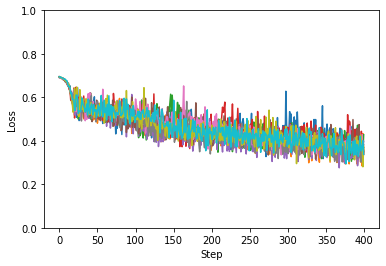

In [ ]:
for train_loss in multi_train_losses:
    plt.plot(train_loss)
    plt.ylim(0, 1)
    
    plt.xlabel('Step')
    plt.ylabel('Loss')

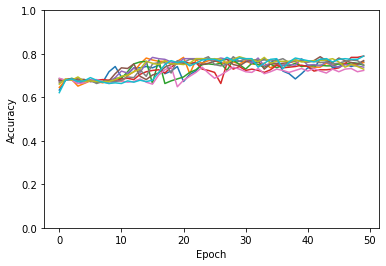

In [ ]:
for test_acc in multi_train_test_accs:
    plt.plot(test_acc)
    plt.ylim(0, 1)
    
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

Text(0, 0.5, 'Accuracy')

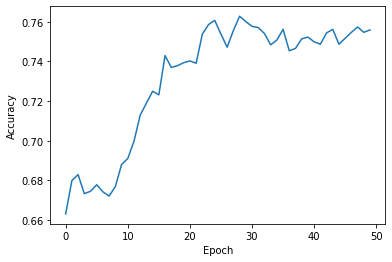

In [ ]:
temp = torch.tensor(multi_train_test_accs)
plt.plot(torch.mean(temp, axis = 0))
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

In [ ]:
print(f"Accuracy on train data (mean, std): {torch.tensor(multi_train_acc).mean()*100:0.3f}, {torch.tensor(multi_train_acc).std()*100:0.3f}")
print(f"Accuracy on test data (mean, std): {torch.tensor(multi_test_acc).mean()*100:0.3f}, {torch.tensor(multi_test_acc).std()*100:0.3f}")

Accuracy on train data (mean, std): 82.990, 0.740
Accuracy on test data (mean, std): 75.586, 2.278
